#### The dataset appears to contain sensor readings from an industrial system, likely related to oil extraction or pumping operations. It includes measurements such as pressure, temperature, motor frequency, water cut, and oil production rates.


In [72]:
# importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


# to building model
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve,mean_absolute_error,mean_squared_error,r2_score

In [55]:
# importing csv
data=pd.read_csv('/Users/mac/Downloads/data-large.csv')
df=data.copy()
df.head()

,Unnamed: 0,ESP01,ESP01.1,ESP01.2,ESP01.3,ESP01.4,ESP01.5,ESP02,ESP02.1,ESP02.2,...,IC01.8,IC02,IC02.1,IC02.2,IC02.3,IC02.4,IC02.5,IC02.6,IC02.7,IC02.8
0,time,DISCHARGE_PRESSURE,INTAKE_PRESSURE,INTAKE_TEMPERATURE,MOTOR_TEMP,VSDFREQOUT,VSDMOTAMPS,DISCHARGE_PRESSURE,INTAKE_PRESSURE,INTAKE_TEMPERATURE,...,OIL_RATE,CHOKE_POSITION,PRESSURE1,PRESSURE2,TEMPERATURE1,TEMPERATURE2,WATER_CUT,LIQUID_RATE,WATER_RATE,OIL_RATE
1,s,psia,psia,K,K,Hz,A,psia,psia,K,...,bbl/d,%,psia,psia,degF,degF,%,bbl/d,bbl/d,bbl/d
2,1370044800,4819440.062,4645092.555,382.8436706,383.0596235,0,2,13935372.4,4230328.642,358.828813,...,0,0,2489,2485,196,193,0.2,0,0,0
3,1370045100,4869044.81,4630605.41,382.8270592,382.9445269,0,2,13064140.62,4141697.565,359.4253646,...,0,0,2489,2485,198,196,0.2,0,0,0
4,1370045400,4824754.919,4684340.8,382.8626879,382.9402203,0,2,14110557.56,4430323.167,357.2496335,...,0,0,2489,2485,195,193,0.5,0,0,0


In [56]:
# checking shape of data
df.shape

(130452, 37)

- there are 130452 rows and 37 columns.

In [57]:
# using first row as header
df.columns = df.loc[0]
df = df[2:].reset_index(drop=True)
df.head()

,time,DISCHARGE_PRESSURE,INTAKE_PRESSURE,INTAKE_TEMPERATURE,MOTOR_TEMP,VSDFREQOUT,VSDMOTAMPS,DISCHARGE_PRESSURE,INTAKE_PRESSURE,INTAKE_TEMPERATURE,...,OIL_RATE,CHOKE_POSITION,PRESSURE1,PRESSURE2,TEMPERATURE1,TEMPERATURE2,WATER_CUT,LIQUID_RATE,WATER_RATE,OIL_RATE
0,1370044800,4819440.062,4645092.555,382.8436706,383.0596235,0,2,13935372.4,4230328.642,358.828813,...,0,0,2489,2485,196,193,0.2,0,0,0
1,1370045100,4869044.81,4630605.41,382.8270592,382.9445269,0,2,13064140.62,4141697.565,359.4253646,...,0,0,2489,2485,198,196,0.2,0,0,0
2,1370045400,4824754.919,4684340.8,382.8626879,382.9402203,0,2,14110557.56,4430323.167,357.2496335,...,0,0,2489,2485,195,193,0.5,0,0,0
3,1370045700,4849769.046,4697244.12,382.862196,382.9384828,0,2,12781664.74,3917750.211,359.2356498,...,0,0,2489,2485,196,198,0.8,0,0,0
4,1370046000,4838199.888,4705090.494,382.855058,382.9485043,0,2,15252131.42,4355878.258,356.3494983,...,0,0,2489,2485,195,196,0.3,0,0,0


In [58]:
# checking data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130450 entries, 0 to 130449
Data columns (total 37 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   time                130450 non-null  object
 1   DISCHARGE_PRESSURE  130450 non-null  object
 2   INTAKE_PRESSURE     130450 non-null  object
 3   INTAKE_TEMPERATURE  130450 non-null  object
 4   MOTOR_TEMP          130450 non-null  object
 5   VSDFREQOUT          130450 non-null  object
 6   VSDMOTAMPS          130450 non-null  object
 7   DISCHARGE_PRESSURE  130450 non-null  object
 8   INTAKE_PRESSURE     130450 non-null  object
 9   INTAKE_TEMPERATURE  130450 non-null  object
 10  MOTOR_TEMP          130450 non-null  object
 11  VSDFREQOUT          130450 non-null  object
 12  VSDMOTAMPS          130450 non-null  object
 13  DISCHARGE_PRESSURE  130450 non-null  object
 14  INTAKE_PRESSURE     130450 non-null  object
 15  INTAKE_TEMPERATURE  130450 non-null  object
 16  MO

In [59]:
# lets fix data types
df=df.astype(float)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130450 entries, 0 to 130449
Data columns (total 37 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   time                130450 non-null  float64
 1   DISCHARGE_PRESSURE  130450 non-null  float64
 2   INTAKE_PRESSURE     130450 non-null  float64
 3   INTAKE_TEMPERATURE  130450 non-null  float64
 4   MOTOR_TEMP          130450 non-null  float64
 5   VSDFREQOUT          130450 non-null  float64
 6   VSDMOTAMPS          130450 non-null  float64
 7   DISCHARGE_PRESSURE  130450 non-null  float64
 8   INTAKE_PRESSURE     130450 non-null  float64
 9   INTAKE_TEMPERATURE  130450 non-null  float64
 10  MOTOR_TEMP          130450 non-null  float64
 11  VSDFREQOUT          130450 non-null  float64
 12  VSDMOTAMPS          130450 non-null  float64
 13  DISCHARGE_PRESSURE  130450 non-null  float64
 14  INTAKE_PRESSURE     130450 non-null  float64
 15  INTAKE_TEMPERATURE  130450 non-nul

- now data types is float which is fine.

In [60]:
# lets check data distribution
df.describe()

,time,DISCHARGE_PRESSURE,INTAKE_PRESSURE,INTAKE_TEMPERATURE,MOTOR_TEMP,VSDFREQOUT,VSDMOTAMPS,DISCHARGE_PRESSURE,INTAKE_PRESSURE,INTAKE_TEMPERATURE,...,OIL_RATE,CHOKE_POSITION,PRESSURE1,PRESSURE2,TEMPERATURE1,TEMPERATURE2,WATER_CUT,LIQUID_RATE,WATER_RATE,OIL_RATE
count,1.304500e+05,1.304500e+05,1.304500e+05,130450.000000,130450.000000,1.304500e+05,130450.000000,1.304500e+05,1.304500e+05,130450.000000,...,130450.000000,130450.000000,130450.000000,130450.000000,130450.000000,130450.000000,130450.000000,130450.000000,130450.0000,130450.000000
mean,1.387787e+09,1.283973e+07,4.868642e+06,390.844720,409.675698,3.463703e+01,153.643032,1.266787e+07,3.893372e+06,356.061139,...,542.621876,81.293415,2457.022553,2419.314442,195.633392,195.420422,46.534904,915.981158,502.2585,413.722658
std,8.818018e+06,5.714941e+06,1.536035e+06,151.062124,255.886965,2.662680e+01,117.365079,1.999764e+06,2.497253e+05,2.756600,...,439.851550,35.465041,14.801382,31.900267,1.695177,1.681024,23.761341,407.294735,267.4234,225.776681
min,1.370045e+09,-9.390000e-21,-7.450000e-21,270.004989,267.919645,-7.750000e-21,0.000000,-9.990000e-21,-9.710000e-21,269.188171,...,0.000000,0.000000,2440.000000,2382.000000,193.000000,193.000000,0.100000,0.000000,0.0000,0.000000
25%,1.380363e+09,5.942929e+06,4.063318e+06,383.550450,384.003302,0.000000e+00,2.000000,1.211004e+07,3.736567e+06,355.324143,...,362.000000,99.000000,2447.000000,2393.000000,194.000000,194.000000,30.000000,872.000000,398.7000,355.600000
50%,1.389685e+09,1.667865e+07,4.758994e+06,384.449007,399.794465,5.104397e+01,228.826695,1.288689e+07,3.886319e+06,356.071186,...,529.999900,99.000000,2454.000000,2417.000000,196.000000,195.000000,60.000000,982.000000,580.2000,453.600000
75%,1.394572e+09,1.722154e+07,5.345022e+06,386.179694,409.175713,5.596162e+01,249.816769,1.411705e+07,4.049481e+06,356.823074,...,555.600000,99.000000,2460.000000,2425.000000,197.000000,197.000000,60.000000,1197.000000,711.0000,483.600000
max,1.402585e+09,2.109104e+07,4.552630e+07,4597.667752,6634.482031,8.482603e+01,441.214112,1.564645e+07,4.702580e+06,363.772887,...,1520.000000,99.000000,2489.000000,2485.000000,198.000000,198.000000,60.000000,1372.000000,754.2000,1083.880000


### Data Preprocessing

In [61]:
# lets check for null values
df.isnull().sum()

0
time                  0
DISCHARGE_PRESSURE    0
INTAKE_PRESSURE       0
INTAKE_TEMPERATURE    0
MOTOR_TEMP            0
VSDFREQOUT            0
VSDMOTAMPS            0
DISCHARGE_PRESSURE    0
INTAKE_PRESSURE       0
INTAKE_TEMPERATURE    0
MOTOR_TEMP            0
VSDFREQOUT            0
VSDMOTAMPS            0
DISCHARGE_PRESSURE    0
INTAKE_PRESSURE       0
INTAKE_TEMPERATURE    0
MOTOR_TEMP            0
VSDFREQOUT            0
VSDMOTAMPS            0
CHOKE_POSITION        0
PRESSURE1             0
PRESSURE2             0
TEMPERATURE1          0
TEMPERATURE2          0
WATER_CUT             0
LIQUID_RATE           0
WATER_RATE            0
OIL_RATE              0
CHOKE_POSITION        0
PRESSURE1             0
PRESSURE2             0
TEMPERATURE1          0
TEMPERATURE2          0
WATER_CUT             0
LIQUID_RATE           0
WATER_RATE            0
OIL_RATE              0
dtype: int64

- there are no missing value.

In [62]:
# lets check for duplicates 
df.duplicated().sum()

0

0                       time  DISCHARGE_PRESSURE  INTAKE_PRESSURE  \
0                                                                   
time                1.000000            0.005992         0.252567   
DISCHARGE_PRESSURE  0.005992            1.000000        -0.230315   
INTAKE_PRESSURE     0.252567           -0.230315         1.000000   
INTAKE_TEMPERATURE -0.086715            0.033703         0.470205   
MOTOR_TEMP         -0.106398            0.072578         0.662985   
VSDFREQOUT          0.032733            0.966036        -0.276363   
VSDMOTAMPS         -0.058014            0.959577        -0.312527   
DISCHARGE_PRESSURE -0.018392           -0.029121        -0.006497   
INTAKE_PRESSURE    -0.053588           -0.032592        -0.013834   
INTAKE_TEMPERATURE -0.013221           -0.014949         0.001142   
MOTOR_TEMP         -0.011196           -0.019677        -0.002923   
VSDFREQOUT          0.010321           -0.031394        -0.013074   
VSDMOTAMPS          0.004140      

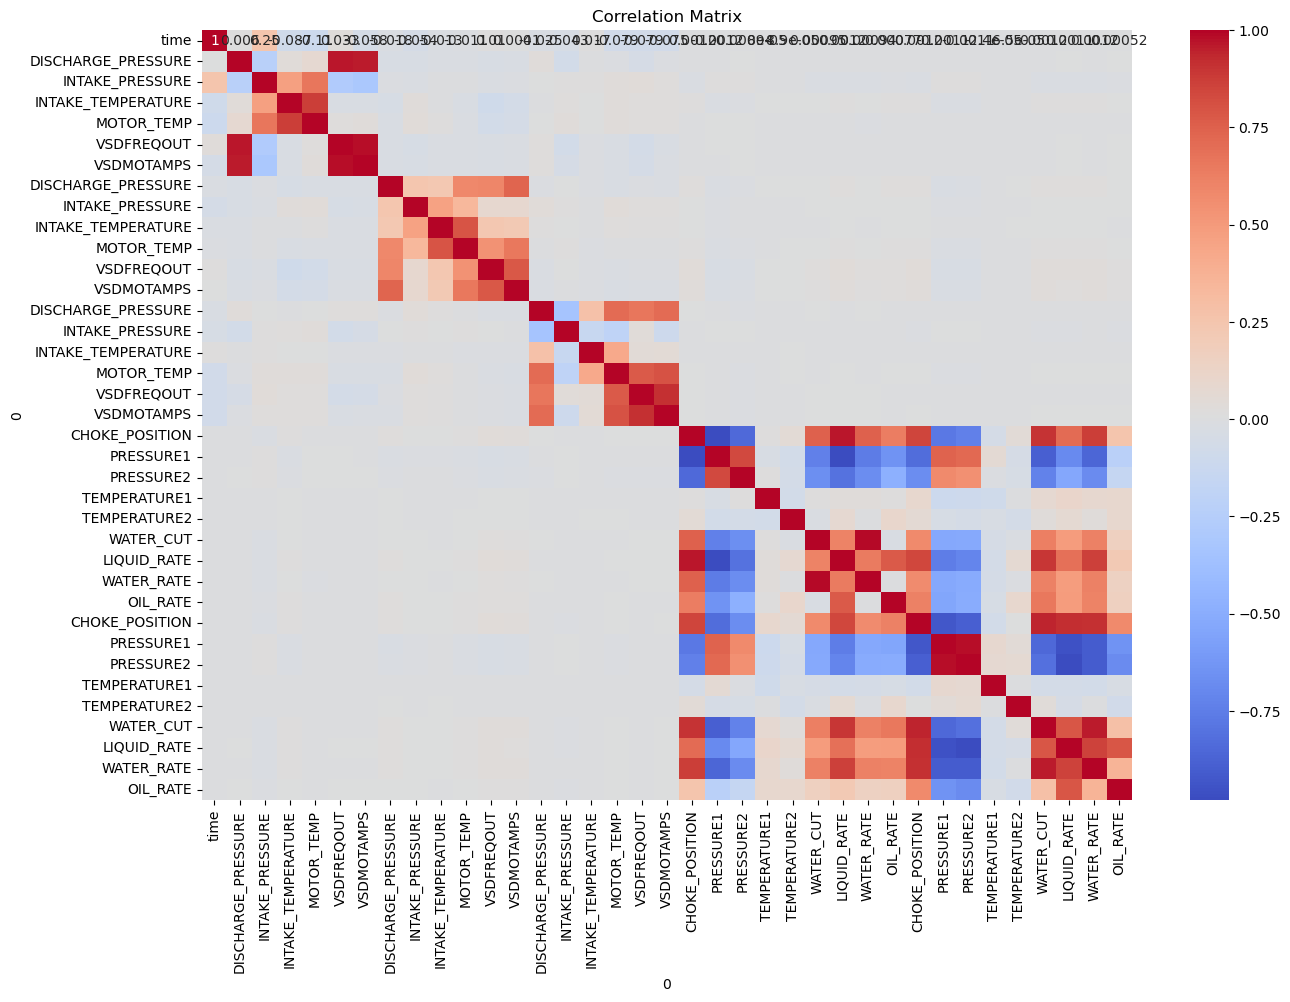

In [88]:
# lets check coorelation
print(df.corr())
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

- discharge pressure is strongly positive correleated with VSDMOTAMPS.

In [63]:
# lets copy data

df1=df.copy()

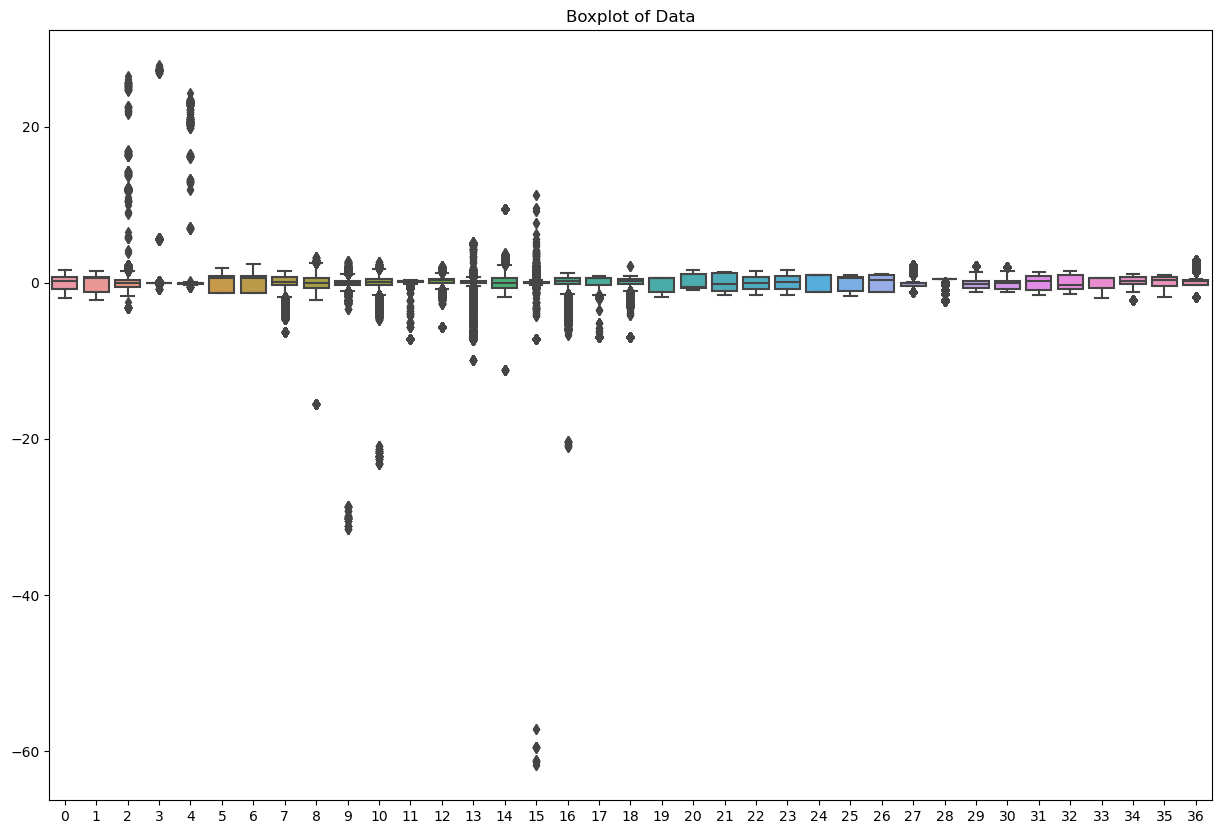

In [86]:
# lets check for outliers
plt.figure(figsize=(15,10))
sns.boxplot(data=df1)
plt.title('Boxplot of Data')
plt.show()

- there are outlier present in data.
- assuming all datapoint is real.

In [100]:
# #lets check for skewness
# sns.pairplot(df, diag_kind='kde')
# plt.show()

In [64]:
# lets scale data
scaler = StandardScaler()
df1 = scaler.fit_transform(df1)

In [69]:
# lets divide data into two parts
X = df1[:, :-1]  # features
y = df1[:, -1]   # target variable

In [71]:
# lets split it into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Model Building

In [77]:
# lets build model
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.1))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='linear'))  # linear activation for regression


In [78]:
# lets compile model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae', 'r2_score'])


In [79]:
# check summary of model
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993 (19.50 KB)

 Trainable params: 4,993 (19.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


2609/2609 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 0.2219 - mae: 0.2735 - r2_score: 0.7806 - val_loss: 0.0126 - val_mae: 0.0778 - val_r2_score: 0.9875
Epoch 2/100
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - loss: 0.0369 - mae: 0.1156 - r2_score: 0.9632 - val_loss: 0.0050 - val_mae: 0.0469 - val_r2_score: 0.9950
Epoch 3/100
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 0.0285 - mae: 0.0974 - r2_score: 0.9713 - val_loss: 0.0057 - val_mae: 0.0490 - val_r2_score: 0.9943
Epoch 4/100
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 0.0245 - mae: 0.0891 - r2_score: 0.9753 - val_loss: 0.0034 - val_mae: 0.0372 - val_r2_score: 0.9966
Epoch 5/100
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.0224 - mae: 0.0852 - r2_score: 0.9775 - val_loss: 0.0093 - val_mae: 0.0438 - val_r2_score: 0.9908
Epoch 6/100
2609/2609 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 0.0210 - mae: 0.0810 - r2_score: 0.9789 - val_loss: 0.0057 - val_mae: 0.0440 - val_r2_score: 0.9943
Epoch 7/100
2609/2609 ━━━━━

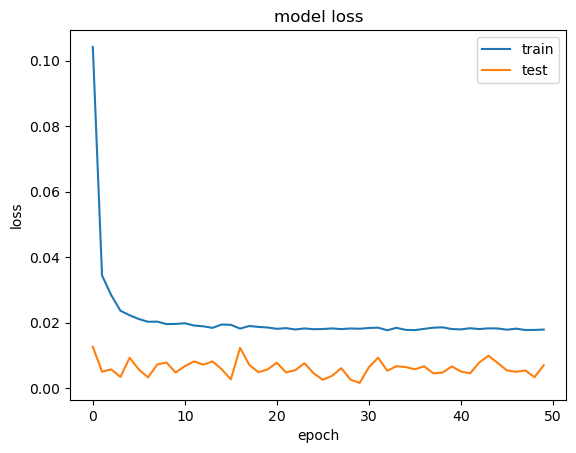

In [80]:
# lets fit model        
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2, callbacks=[early_stopping], verbose=1)

# lets check history
history.history.keys()
# lets plot history
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper right')
plt.show()

In [83]:
# lets check model performance on test data
y_pred = model.predict(X_test)
# lets check performance metrics
mae_test = mean_absolute_error(y_test, y_pred)  
r2_test = r2_score(y_test, y_pred)
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
print("Test MAE:", mae_test)
print("Test R2:", r2_test)
print("Test MSE:", mse_test)
print("Test RMSE:", rmse_test)     

816/816 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Test MAE: 0.01761301352976736
Test R2: 0.9983203065773109
Test MSE: 0.0016789165288404733
Test RMSE: 0.040974583937368705


#### Conclusion

- mode is performing well on train-val-test set means its generalized model.
- R2_score is around 99%  
- mae is around 0.2
- mse is around 0.002
- rmse is around 0.4